# Extended Data 05 — SEN threshold and regional-domain sensitivity

This notebook tests whether the fire-specific and regional Structure Exposure Network results depend on the selected geometric-coupling threshold, the use of a common rather than fire-specific calibration, or the width of the regional WUI screen. The primary analysis remains the pooled single-emitter coupling corresponding to an absolute fitted $P(\mathrm{destroyed})=0.50$.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.analysis.fragility import FIRES
from src.analysis.sen import (
    build_within_perimeter_network, pooled_single_emitter_threshold,
)
from src.analysis.sen_sensitivity import (
    fire_calibration_comparison, fire_specific_probability_thresholds,
    fire_threshold_sweep, regional_domain_sensitivity,
    regional_threshold_sweep,
)
from src.viz.sen_sensitivity import plot_sen_sensitivity

DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
CACHE = SOURCE_DATA / 'sen_cache'
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
for directory in [RESULTS, SOURCE_DATA, CACHE, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
PROBABILITIES = np.array([.20, .35, .50, .65, .80])

## Pooled and fire-specific calibrations

For clarity, the absolute fitted 50% probability threshold and the asymptotic fragility midpoint, $F_{50}$, are reported separately. They need not be identical because the fitted lower and upper asymptotes are not constrained to zero and one.

In [2]:
analysis = pd.read_parquet(DATA / 'analysis.parquet')
pooled_fit, _ = pooled_single_emitter_threshold(DATA)
thresholds = fire_specific_probability_thresholds(analysis, pooled_fit)
thresholds.to_csv(RESULTS / 'ED05_sen_probability_thresholds.csv', index=False)
display(thresholds.round(6))

,calibration,fire,probability_equivalent,F_ij_threshold,fragility_midpoint_F50,n
0,Pooled,POOLED,0.5,0.026503,0.026041,25127
1,Eaton,EATON,0.5,0.024177,0.022839,14595
2,Palisades,PALISADES,0.5,0.033329,0.034375,10532


## Within-fire threshold sensitivity

The perimeter-induced Eaton and Palisades networks were rebuilt at five pooled response-equivalent thresholds. The fixed-size outcome contrast compares destruction among buildings in SENs of at least 100 buildings with isolated buildings; unlike within-threshold quantiles, this definition remains directly comparable as the network fragments.

In [3]:
networks = {
    fire: build_within_perimeter_network(DATA, fire, cache_dir=CACHE)
    for fire in FIRES
}
fire_sweep = fire_threshold_sweep(
    networks, analysis, pooled_fit, PROBABILITIES)
calibration_comparison = fire_calibration_comparison(
    networks, analysis, thresholds)
fire_sweep.to_csv(RESULTS / 'ED05_fire_threshold_sweep.csv', index=False)
calibration_comparison.to_csv(
    RESULTS / 'ED05_fire_calibration_comparison.csv', index=False)
display(fire_sweep[[
    'fire', 'probability_equivalent', 'F_ij_threshold',
    'largest_component', 'connected_buildings',
    'large_minus_isolated_pp',
]].round(4))
display(calibration_comparison[[
    'fire', 'calibration', 'F_ij_threshold', 'largest_component',
    'large_minus_isolated_pp',
]].round(4))

,fire,probability_equivalent,F_ij_threshold,largest_component,connected_buildings,large_minus_isolated_pp
0,EATON,0.20,0.0079,5421,12547,28.7984
1,PALISADES,0.20,0.0079,3091,9260,32.7752
2,EATON,0.35,0.0163,169,11721,8.8076
3,PALISADES,0.35,0.0163,1254,8763,42.2296
4,EATON,0.50,0.0265,101,10523,4.9722
5,PALISADES,0.50,0.0265,498,8199,39.2175
6,EATON,0.65,0.0411,56,8934,NaN
7,PALISADES,0.65,0.0411,104,7400,37.9215
8,EATON,0.80,0.0695,22,6740,NaN
9,PALISADES,0.80,0.0695,26,6163,NaN


,fire,calibration,F_ij_threshold,largest_component,large_minus_isolated_pp
0,EATON,Common pooled,0.0265,101,4.9722
1,EATON,Fire-specific,0.0242,102,5.7862
2,PALISADES,Common pooled,0.0265,498,39.2175
3,PALISADES,Fire-specific,0.0333,107,40.0841


## Regional threshold and domain sensitivity

The Santa Monica Mountains network was rebuilt at the same five thresholds. Domain sensitivity then induced the primary-threshold network among buildings within 500, 750 and 1,000 m of the route-selected Interface spine and compared these with the production corridor.

In [4]:
regional_sweep = regional_threshold_sweep(
    PROJECT_ROOT, pooled_fit, PROBABILITIES)
primary_threshold = float(
    thresholds.loc[thresholds.fire.eq('POOLED'), 'F_ij_threshold'].iloc[0])
domain_sensitivity = regional_domain_sensitivity(
    PROJECT_ROOT, primary_threshold, buffers=(500, 750, 1000))
regional_sweep.to_csv(RESULTS / 'ED05_regional_threshold_sweep.csv', index=False)
domain_sensitivity.to_csv(
    RESULTS / 'ED05_regional_domain_sensitivity.csv', index=False)
display(regional_sweep[[
    'probability_equivalent', 'F_ij_threshold', 'largest_SEN',
    'connected_building_share', 'share_in_interface_spanning_SENs',
]].round(4))
display(domain_sensitivity[[
    'domain', 'buildings', 'largest_SEN',
    'share_in_interface_spanning_SENs',
]].round(4))

,probability_equivalent,F_ij_threshold,largest_SEN,connected_building_share,share_in_interface_spanning_SENs
0,0.20,0.0079,54682,0.9614,0.9063
1,0.35,0.0163,28167,0.9508,0.7900
2,0.50,0.0265,9619,0.9360,0.5304
3,0.65,0.0411,1228,0.9129,0.2301
4,0.80,0.0695,259,0.8692,0.1199


,domain,buildings,largest_SEN,share_in_interface_spanning_SENs
0,Within 500 m of Interface spine,75063,5061,0.5528
1,Within 750 m of Interface spine,96438,7437,0.5376
2,"Within 1,000 m of Interface spine",115090,9619,0.5304
3,Production corridor,115111,9619,0.5304


## Extended Data Figure 5

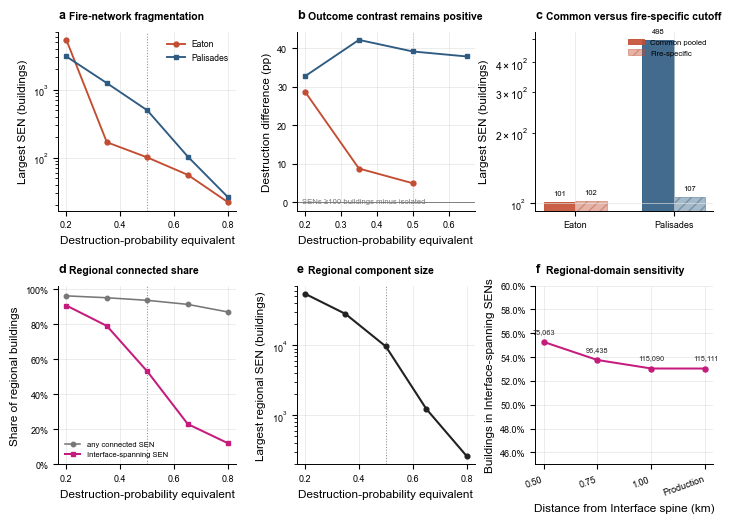

saved ./figures/extended_data/ED_fig_sen_sensitivity.png


In [5]:
figure_source = {
    'fire_threshold_sweep': fire_sweep,
    'fire_calibration_comparison': calibration_comparison,
    'regional_threshold_sweep': regional_sweep,
    'regional_domain_sensitivity': domain_sensitivity,
}
for name, frame in figure_source.items():
    frame.to_csv(SOURCE_DATA / f'ED_fig_sen_sensitivity_{name}.csv', index=False)
fig = plot_sen_sensitivity(
    fire_sweep, calibration_comparison, regional_sweep,
    domain_sensitivity, FIGURES)
plt.show()
print('saved', FIGURES / 'ED_fig_sen_sensitivity.png')

## Interpretation

Component size is necessarily threshold-dependent: increasingly stringent coupling cutoffs fragment both fire and regional networks. Nevertheless, destruction remained higher among buildings in large than isolated SENs wherever components of at least 100 buildings remained, and the regional Interface-spanning share changed smoothly rather than discontinuously around the primary threshold. Restricting the regional domain from the production corridor to 500–1,000 m from the selected Interface spine produced similar Interface-spanning shares. Fire-specific calibration changed component sizes in the expected direction because Eaton's fitted 50% cutoff was lower and Palisades' was higher than the pooled cutoff; the main analysis retains the common threshold to compare built-form connectivity on the same scale.

In [6]:
import importlib.metadata as metadata
versions = pd.DataFrame({
    'package': ['python', 'numpy', 'pandas', 'geopandas', 'scipy', 'matplotlib'],
    'version': [sys.version.split()[0]] + [
        metadata.version(name) for name in
        ['numpy', 'pandas', 'geopandas', 'scipy', 'matplotlib']
    ],
})
display(versions)

,package,version
0,python,3.10.18
1,numpy,2.2.6
2,pandas,2.3.3
3,geopandas,1.1.1
4,scipy,1.15.2
5,matplotlib,3.9.4
